# 03 — EDA: churn หน้าตาเป็นยังไง

บท 01 เราสร้าง label · บท 02 เราจัดข้อมูล 2 ปีให้อยู่ schema เดียวกัน —
บทนี้ถึงเวลา **เปิดไฟดูบ้านตัวเอง** ครับ: ก่อนจะยกงานให้โมเดล เราต้องเห็น
pattern ของ churn ด้วยตาตัวเองก่อน ด้วยเหตุผล 3 ข้อ

1. **จับข้อมูลผิดได้เร็ว** — กราฟที่ "หน้าตาแปลก" มักแปลว่า wrangling พลาด ไม่ใช่ insight
2. **ได้ไอเดีย feature ฟรีๆ** — signal ที่เห็นด้วยตาในบทนี้ จะกลายเป็นคอลัมน์ features ในบท 04
3. **ได้เรื่องเล่าที่ทีมเชื่อ** — "เด็ก attendance ต่ำหายมากกว่า 10 จุด" ขายง่ายกว่า "AP = 0.22" เยอะ

**สิ่งที่จะได้จากบทนี้ (~75 นาที)**

1. churn rate รายเดือน เทียบ 2 ซีซัน — เห็นว่าเดือนไหน mentor ต้องเทแรง
2. **survival curve** — จาก 100 คนตอนต้นซีซัน เหลือกี่คนเมื่อเวลาผ่านไป
3. พฤติกรรมก่อนหาย: attendance กับ silent_weeks ของ churner ต่างจากคนที่อยู่ต่อแค่ไหน
4. เปิดโจทย์อิสระ — เลือกมุมที่คุณสงสัยเอง แล้ว groupby หาคำตอบด้วยมือตัวเอง
5. เครื่องมือติดตัว: `pivot_table` · `cumprod` · `groupby().last()` · `crosstab` · boxplot

In [1]:
import os; os.environ.setdefault("ML_CHURN_DATA", "sample")  # repo สาธารณะรันบนข้อมูลสังเคราะห์ (โปรเจกต์ภายในตั้ง =real)
import sys; sys.path.insert(0, "..")
import pandas as pd
from src import checks, churn_utils, contracts
from src.config import DATA_DIR, IS_SAMPLE
plt = churn_utils.plot_style()
print("โหมดข้อมูล:", "SAMPLE (ข้อมูลจำลอง)" if IS_SAMPLE else f"REAL ({DATA_DIR})")

โหมดข้อมูล: SAMPLE (ข้อมูลจำลอง)


In [2]:
import numpy as np

# วัตถุดิบของบทนี้ 3 ตาราง (ผลงานบท 01–02 — schema ตาม docs/data-dictionary.md)
labels = pd.read_csv(DATA_DIR / "labels_monthly.csv", dtype={"month": str}, parse_dates=["churn_date"])
wm = pd.read_csv(DATA_DIR / "weekly_metrics.csv", parse_dates=["week_start", "week_end"])
students = pd.read_csv(DATA_DIR / "students.csv", parse_dates=["signup_date"])

print(f"labels   {labels.shape} — 1 แถว = (นักเรียน, เดือนที่ active) + churned_next_month")
print(f"wm       {wm.shape} — 1 แถว = (นักเรียน, สัปดาห์) จากระบบติดตามของเรา")
print(f"students {students.shape} — 1 แถว = นักเรียน 1 คน/ปี")
print(f"\nchurn rate รวม (เฉพาะเดือนที่มี label): {labels['churned_next_month'].mean():.1%}")

labels   (1610, 7) — 1 แถว = (นักเรียน, เดือนที่ active) + churned_next_month
wm       (7620, 17) — 1 แถว = (นักเรียน, สัปดาห์) จากระบบติดตามของเรา
students (310, 14) — 1 แถว = นักเรียน 1 คน/ปี

churn rate รวม (เฉพาะเดือนที่มี label): 8.8%


## [แนวคิด] 3.1 churn รายเดือน — กราฟแรกที่เจ้าของธุรกิจควรดู

คำถามแรกของ EDA ควรเป็นคำถามที่ธุรกิจอยากรู้ที่สุด: **เดือนไหนน้องหายเยอะ?**
เพราะคำตอบสั่งงานได้ทันที — เดือน peak คือเดือนที่ mentor ต้องโทรถี่ขึ้น
และเป็นเดือนที่โมเดลของเราต้องแม่นที่สุด

เครื่องมือคือ `pivot_table` — ตารางสรุปแบบ "แถว × คอลัมน์" ท่าเดียวกับ
pivot ใน Google Sheets ที่คุณใช้อยู่แล้ว:

- `index=` มิติที่อยากไล่ลงมาเป็นแถว (เดือนของซีซัน)
- `columns=` มิติที่อยากเทียบเคียงข้างกัน (ปี 2568 vs 2569)
- `values=` + `aggfunc=` เอาค่าไหนมาสรุปด้วยวิธีไหน (mean ของ label 0/1 = churn rate พอดี)

trick สำคัญ: เดือนอยู่ในรูป `"2025-07"` ซึ่งปีติดมาด้วย เทียบข้ามปีตรงๆ ไม่ได้
→ ตัดเอาเฉพาะเลขเดือนด้วย `.str[5:]` (`"2025-07"` → `"07"`) แล้วสองปีจะขึ้นแกนเดียวกัน

In [3]:
# ตัวอย่าง (เคสคู่ขนาน): จำนวนนักเรียน active รายเดือน แยกปี — pivot_table ท่าเดียวกัน
demo = labels.copy()
demo["mon"] = demo["month"].str[5:]        # "2025-07" → "07" (เลขเดือน ใช้เทียบข้ามปี)
active_pivot = demo.pivot_table(index="mon", columns="year", values="active", aggfunc="sum")
print(active_pivot)
print("\nปี 68 เริ่ม มี.ค. 102 คน พุ่งเป็น 144 ตอน มิ.ย. (น้องสมัครช้าทยอยเข้า) แล้วค่อยๆ ลด")
print("ตัวเลขนี้คือ 'ตัวหาร' ของ churn rate — เก็บภาพนี้ไว้ตีความข้อถัดๆ ไปครับ")

year  2568  2569
mon             
03     102   108
04     132   124
05     140   119
06     144   113
07     132   106
08     113    93
09     100    84

ปี 68 เริ่ม มี.ค. 102 คน พุ่งเป็น 144 ตอน มิ.ย. (น้องสมัครช้าทยอยเข้า) แล้วค่อยๆ ลด
ตัวเลขนี้คือ 'ตัวหาร' ของ churn rate — เก็บภาพนี้ไว้ตีความข้อถัดๆ ไปครับ


### [แบบฝึกหัด 3.1] churn rate รายเดือน แยกปี

สลับจาก "นับคน active" เป็น "อัตราการหาย" ของแต่ละเดือน

**คำสั่ง**

1. เพิ่มคอลัมน์ `mon` ใน `labels` = เลขเดือน 2 หลัก (ตัดจาก `month` ด้วย `.str[5:]`)
2. สร้าง `churn_pivot` ด้วย `pivot_table`: แถว = `mon` · คอลัมน์ = `year` ·
   ค่า = **ค่าเฉลี่ย** ของ `churned_next_month`
3. เก็บเป็นสัดส่วน 0–1 (อย่าเพิ่งคูณ 100 — check ต้องการสัดส่วน)
   เดือน censored จะเป็น NaN เอง เพราะ pandas ข้าม NaN ให้ตอนเฉลี่ย

**ผลลัพธ์ที่คาด (sample):** DataFrame 6 แถว (mon 03–08) × 2 คอลัมน์ (2568, 2569) —
ปี 68 ก.ค. ควรราวๆ 0.14 · ปี 69 มี.ค. ราวๆ 0.12

In [4]:
____ = None  # TODO: เติมโค้ดแทน ____ ทีละจุด

# TODO 1: เลขเดือน 2 หลัก จากคอลัมน์ month (ดูตัวอย่าง active_pivot ได้เลย)
labels["mon"] = labels["month"].str[5:]
# TODO 2: pivot_table — แถว=mon, คอลัมน์=year, ค่าเฉลี่ยของ churned_next_month
churn_pivot = labels.pivot_table(index="mon", columns="year" , values= "churned_next_month" , aggfunc = "mean")

if churn_pivot is not None:
    print((churn_pivot * 100).round(1))
checks.check("ex_03_01", churn_pivot)

year  2568  2569
mon             
03     4.9  12.0
04     4.5  10.5
05     3.6   9.2
06     8.3   6.2
07    14.4  12.3
08    11.5   NaN
ผ่าน ✓  (ex_03_01) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

โครงเดียวกับตัวอย่าง active_pivot เป๊ะ — เปลี่ยนแค่ 2 อย่าง: ค่าที่เอามาสรุป
เปลี่ยนจากจำนวนคน active เป็นคอลัมน์ label และวิธีสรุปเปลี่ยนจากผลรวมเป็นค่าเฉลี่ย
(ค่าเฉลี่ยของคอลัมน์ 0/1 = สัดส่วนที่เป็น 1 — trick เดิมจากบท 01)

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `.str[5:]`
- `.pivot_table(index=..., columns=..., values=..., aggfunc="mean")`

</details>

In [5]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_03_01.py

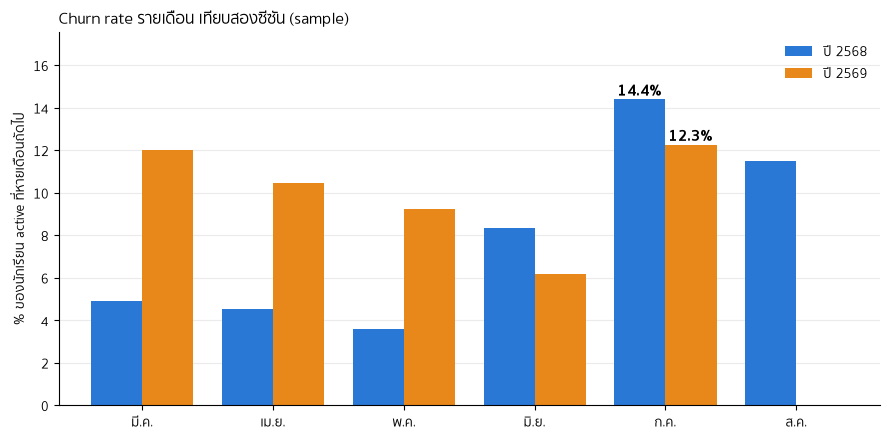

In [6]:
# กราฟแท่งเทียบสองปี — cell นี้คำนวณจากไฟล์ตรงๆ (รันได้เสมอ ไม่พึ่งคำตอบข้อไหน)
_lab = pd.read_csv(DATA_DIR / "labels_monthly.csv", dtype={"month": str})
_lab["mon"] = _lab["month"].str[5:]
_pv = _lab.pivot_table(index="mon", columns="year", values="churned_next_month", aggfunc="mean")

THAI_MON = {"03": "มี.ค.", "04": "เม.ย.", "05": "พ.ค.", "06": "มิ.ย.",
            "07": "ก.ค.", "08": "ส.ค.", "09": "ก.ย."}
YEAR_COLORS = {2568: "#2a78d6", 2569: "#e8871a"}   # สีประจำปี — ใช้ซ้ำทั้งบทให้จำง่าย

fig, ax = plt.subplots(figsize=(9, 4.5))
(_pv * 100).rename(index=THAI_MON).plot.bar(
    ax=ax, color=[YEAR_COLORS[c] for c in _pv.columns], width=0.78, rot=0)
for cont, year in zip(ax.containers, _pv.columns):   # direct label เฉพาะจุด peak ของแต่ละปี
    v = (_pv[year] * 100).to_numpy(dtype=float)
    j = int(np.nanargmax(v))
    ax.annotate(f"{v[j]:.1f}%", (cont[j].get_x() + cont[j].get_width() / 2, v[j]),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, float(np.nanmax((_pv * 100).to_numpy(dtype=float))) * 1.22)   # เผื่อที่ให้ label
ax.set_title("Churn rate รายเดือน เทียบสองซีซัน (sample)", loc="left")
ax.set_ylabel("% ของนักเรียน active ที่หายเดือนถัดไป")
ax.set_xlabel("")
ax.legend([f"ปี {c}" for c in _pv.columns], frameon=False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### อ่านกราฟแบบเจ้าของธุรกิจ

- **ปี 68: peak ก.ค. (14.4%) แล้วยังสูงต่อ ส.ค. (11.5%)** — ตรง business prior ของเราเลย:
  กลางคอร์สคือช่วง "ท้อสะสม" (เรียนมา 4 เดือน เนื้อหายากขึ้น ผลสอบ checkpoint เริ่มฟ้อง)
  บวกกับใกล้ประกาศรับสมัครสอบจริง หลายบ้านนั่งประเมิน "ไปต่อ หรือเปลี่ยนแผน"
  ก่อนตัดสินใจลงคอร์สโค้งสุดท้าย
- **ปี 69: มี.ค. สูงผิดตา (12.0%)** — เดือนแรกมีธรรมชาติ "ทดลองเรียน"
  สมัครแล้วถอยเร็วถ้าไม่ใช่ · แล้วก็ขึ้นมา peak ก.ค. (12.3%) เหมือนปีก่อน
- แปลเป็นงาน mentor: **เดือนแรกของน้องใหม่ + ช่วง มิ.ย.–ส.ค. คือหน้างานหลัก** —
  และเดือนพวกนี้แหละที่โมเดลบท 05 ต้องพิสูจน์ตัวเอง
- ปี 69 เดือน ส.ค. ไม่มีแท่ง เพราะ censored (บันทึกยังปิดยอดไม่ครบ — บท 01) ไม่ใช่ churn เป็น 0!

## [แนวคิด] 3.2 survival curve — จาก 100 คน เหลือกี่คน

churn rate รายเดือนตอบทีละเดือน แต่คำถามที่เจ็บกว่าคือ **ผลสะสม**:
"น้องที่เริ่มกับเราตอน มี.ค. 100 คน อยู่ถึงปลายซีซันกี่คน?"

วิธีคิดเป็นขั้นบันได:

1. เดือนไหน churn rate = r → สัดส่วนที่ **อยู่ต่อ** เดือนนั้น = `1 - r` (retention)
2. จะรอดถึงเดือนที่ 3 ต้องรอดเดือน 1 **และ** เดือน 2 **และ** เดือน 3
   → เอา retention มา **คูณทบกัน** = `cumprod()` (cumulative product)
3. เส้นที่ได้เรียกว่า **survival curve** — เครื่องมือมาตรฐานของงาน churn ทุกวงการ
   (สาย subscription ดูเส้นนี้ก่อนเส้นอื่นเสมอ)

โน้ตให้ตรง: เส้นนี้คือ "อัตรารอดสะสมของ cohort สมมุติ 100 คนที่อยู่ตั้งแต่ มี.ค."
— ของจริงมีน้องสมัครช้าเข้ามาระหว่างทาง (เห็นใน `active_pivot` แล้ว)
จำนวนคนจริงเลยไม่ได้ลดตามเส้นนี้เป๊ะ แต่ shape ของความเสี่ยงคือตัวนี้

In [7]:
# ตัวอย่าง (เคสคู่ขนาน): คลาสสมมุติ churn 10% → 20% → 5% สามเดือน
toy_rate = pd.Series([0.10, 0.20, 0.05], index=["เดือน 1", "เดือน 2", "เดือน 3"])
toy_retention = 1 - toy_rate
toy_survival = toy_retention.cumprod()
print(pd.DataFrame({"churn_rate": toy_rate, "อยู่ต่อเดือนนั้น": toy_retention,
                    "ยังอยู่สะสม": toy_survival}).round(3))
print("\nเดือน 2: 0.90 × 0.80 = 0.72 → จาก 100 คนเหลือ 72 · เดือน 3 เหลือ ~68")
print("cumprod ก็แค่ 'คูณทบลงมาเรื่อยๆ' — ดอกเบี้ยทบต้นเวอร์ชันนักเรียนหาย")

         churn_rate  อยู่ต่อเดือนนั้น  ยังอยู่สะสม
เดือน 1        0.10              0.90        0.900
เดือน 2        0.20              0.80        0.720
เดือน 3        0.05              0.95        0.684



เดือน 2: 0.90 × 0.80 = 0.72 → จาก 100 คนเหลือ 72 · เดือน 3 เหลือ ~68
cumprod ก็แค่ 'คูณทบลงมาเรื่อยๆ' — ดอกเบี้ยทบต้นเวอร์ชันนักเรียนหาย


### [แบบฝึกหัด 3.2] survival curve เทียบ 2 ปี

ทำขั้นบันไดเดียวกันกับ `churn_pivot` จากข้อ 3.1 ทั้งตาราง (ทีเดียว 2 ปี)
— ถ้าข้อ 3.1 ยังไม่ผ่าน เปิดเฉลยข้อ 3.1 ก่อนนะครับ

**คำสั่ง**

1. `retention` = 1 - `churn_pivot` (pandas ลบทั้งตารางให้เลย)
2. `survival` = `retention.cumprod()` — คูณทบจากเดือนแรกลงมา
   (เดือนที่เป็น NaN จะติด NaN ต่อเอง ไม่ต้องจัดการเพิ่ม)
3. เก็บเป็นสัดส่วน 0–1 เหมือนเดิม

**ผลลัพธ์ที่คาด (sample):** ปี 68 ถึงสิ้น ส.ค. เหลือ ~0.61 · ปี 69 ถึงสิ้น ก.ค. เหลือ ~0.59

In [8]:
____ = None  # TODO: เติมโค้ดแทน ____

# TODO 1: สัดส่วนที่อยู่ต่อในแต่ละเดือน = 1 - churn rate
retention = 1-churn_pivot
# TODO 2: อัตรารอดสะสม — คูณทบลงมาตามแถว
survival = retention.cumprod()

if survival is not None:
    print((survival * 100).round(1))
checks.check("ex_03_02", survival)

year  2568  2569
mon             
03    95.1  88.0
04    90.8  78.7
05    87.5  71.5
06    80.2  67.0
07    68.7  58.8
08    60.8   NaN
ผ่าน ✓  (ex_03_02) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

สองบรรทัดตรงตามตัวอย่าง toy เลยครับ — ต่างแค่คราวนี้เป็น DataFrame 2 คอลัมน์
(pandas กระจายการลบและ cumprod ให้ทีละคอลัมน์เอง ไม่ต้องวนลูป)

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- เครื่องหมายลบธรรมดา: `1 - ...` (pandas กระจายให้ทั้งตาราง)
- `.cumprod()`

</details>

In [9]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_03_02.py

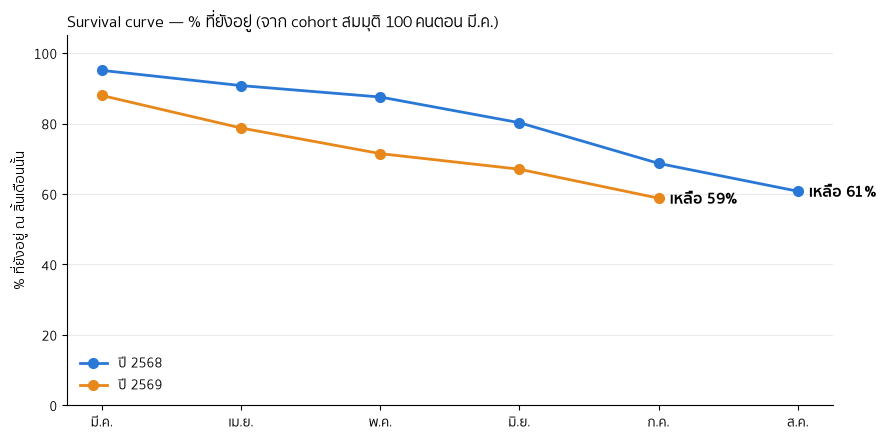

In [10]:
# เส้น survival เทียบสองปี — คำนวณจากไฟล์ตรงๆ (รันได้เสมอ)
_surv = (1 - _pv).cumprod() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
_mons = list(_surv.index)
_xs = np.arange(len(_mons))
for year in _surv.columns:
    s = _surv[year].to_numpy(dtype=float)
    ax.plot(_xs, s, marker="o", ms=7, lw=2, color=YEAR_COLORS[year], label=f"ปี {year}")
    j = int(np.where(~np.isnan(s))[0][-1])          # จุดสุดท้ายที่มีข้อมูล
    ax.annotate(f"เหลือ {s[j]:.0f}%", (_xs[j], s[j]), xytext=(8, -4),
                textcoords="offset points", fontsize=11, fontweight="bold")
ax.set_xticks(_xs, [THAI_MON[m] for m in _mons])
ax.set_ylim(0, 105)
ax.set_title("Survival curve — % ที่ยังอยู่ (จาก cohort สมมุติ 100 คนตอน มี.ค.)", loc="left")
ax.set_ylabel("% ที่ยังอยู่ ณ สิ้นเดือนนั้น")
ax.legend(frameon=False, loc="lower left")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### อ่านเส้น survival

- **ปี 68 เหลือ ~61% ตอนสิ้น ส.ค.** — น้องราว 4 ใน 10 ที่เริ่มต้นซีซัน ไปไม่ถึงโค้งสุดท้าย
  นี่คือขนาดของปัญหาที่โปรเจกต์นี้เกิดมาเพื่อแก้ครับ
- **ปี 69 เส้นดิ่งแรงตั้งแต่ต้น** (แค่ มี.ค.–เม.ย. ก็หายไปแล้ว ~21%) จากเอฟเฟกต์ "ทดลองเรียน"
  แล้วชันน้อยลงกลางซีซัน — สิ้น ก.ค. เหลือ ~59% ขณะที่ปี 68 ณ เดือนเดียวกันยังเหลือ ~69%
  **ปี 69 หนักกว่าราว 10 จุด** ที่จุดเทียบเดียวกัน — เหตุผลที่โปรเจกต์นี้ควรเสร็จก่อนซีซันหน้า
- มุมเงิน: ทุก 1 จุดของเส้นนี้ที่ยกขึ้นได้ = subscription รายเดือนที่ไหลต่อ —
  ถ้า mentor ดึงน้องกลับได้สัก 5 จุด กับฐาน ~150 คน/ปี ก็คือน้องราว 7–8 คน × ค่าคอร์สหลายเดือน

> ⚠️ **กับดัก survivorship bias!** คนที่อยู่ถึง ส.ค. คือคนที่ "รอดมาแล้ว 5 รอบคัดออก"
> ค่าเฉลี่ยอะไรก็ตามของเดือนท้ายซีซัน (attendance, คะแนนสอบ) จะดูดีเป็นพิเศษ —
> ไม่ใช่เพราะเดือนท้ายทำให้เด็กขยันขึ้น แต่เพราะ**เด็กที่ไม่ไหวออกไปหมดแล้ว**
> เพราะงั้นห้ามสรุปว่า "สอนช่วงท้ายดีกว่า" จากค่าเฉลี่ยรายเดือนดิบๆ
> และตอนสร้าง feature บท 04 เราจะเทียบพฤติกรรม ณ เดือน t กับ label ของเดือน t ด้วยกันเสมอ
> ไม่เอาค่าเฉลี่ยของ "ผู้รอดชีวิต" ไปปนกับทุกคน

## [แนวคิด] 3.3 พฤติกรรมก่อนหาย (1) — attendance ฟ้องไหม?

เห็นแล้วว่า "เดือนไหน" หาย — คำถามถัดไปสำคัญกว่าสำหรับโมเดล: **"คนแบบไหน" กำลังจะหาย?**
เริ่มจาก suspect เบอร์หนึ่งที่ทีม mentor เชื่อมานาน: การเข้าเรียน

แผนคือจับ 2 ตารางมาชนกัน:

1. `wm` เป็นรายสัปดาห์ แต่ label เป็นรายเดือน → ต้องสรุป wm ให้เหลือ
   **1 แถวต่อ (นักเรียน, เดือน)** ก่อน โดยใช้ **สัปดาห์สุดท้ายของเดือน** เป็นตัวแทน
   (ท่า `sort_values` → `groupby` → `.last()` — ท่าเดิมจากบท 00 แต่คราวนี้ groupby 2 ชั้น)
2. merge เข้ากับ `labels` ด้วยกุญแจ 2 ดอก `["student_key", "month"]`
   → แต่ละแถวจะมีทั้ง "พฤติกรรมเดือน t" และ "หายเดือนหน้าไหม" อยู่ด้วยกัน
3. ตัดแถว label NaN (censored) ทิ้ง — เทียบได้เฉพาะเดือนที่รู้คำตอบจริง

แล้วดูด้วย **boxplot**: กล่องคือ 50% ตรงกลางของข้อมูล เส้นกลางกล่องคือ median —
เทียบสองกล่อง (อยู่ต่อ vs churn) แวบเดียวรู้เลยว่าต่างกันจริงหรือแค่ฝุ่น

In [11]:
# ตัวอย่าง (เคสคู่ขนาน): จับ "สัปดาห์สุดท้ายของเดือน" จากตารางจิ๋ว 1 คน 2 เดือน
toy_wm = pd.DataFrame({
    "student_key": ["A", "A", "A", "A"],
    "week_start": pd.to_datetime(["2026-03-02", "2026-03-09", "2026-04-06", "2026-04-13"]),
    "att_cum_pct": [100.0, 80.0, 75.0, 70.0],
})
toy_wm["month"] = toy_wm["week_start"].dt.strftime("%Y-%m")   # datetime → "YYYY-MM"
toy_snap = (toy_wm.sort_values("week_start")
                  .groupby(["student_key", "month"], as_index=False).last())
print(toy_snap)
print("\nเหลือเดือนละแถวเดียว: มี.ค. ปิดที่ 80.0 · เม.ย. ปิดที่ 70.0 (ค่า ณ สัปดาห์ท้ายสุด)")

# ต่ออีกนิด — merge ครั้งแรกของหลักสูตร: ประกบ label รายเดือนเข้ากับ snapshot ด้วยกุญแจ 2 ดอก
toy_labels = pd.DataFrame({"student_key": ["A", "A"], "month": ["2026-03", "2026-04"],
                           "churned_next_month": [0.0, 1.0]})
toy_joined = toy_labels.merge(toy_snap, on=["student_key", "month"], how="left")
print("\n", toy_joined, sep="")
print("\nแต่ละแถวมีทั้ง 'พฤติกรรมเดือน t' (att_cum_pct) และ 'หายเดือนหน้าไหม' (label) อยู่ด้วยกันแล้ว")

  student_key    month week_start  att_cum_pct
0           A  2026-03 2026-03-09         80.0
1           A  2026-04 2026-04-13         70.0

เหลือเดือนละแถวเดียว: มี.ค. ปิดที่ 80.0 · เม.ย. ปิดที่ 70.0 (ค่า ณ สัปดาห์ท้ายสุด)

  student_key    month  churned_next_month week_start  att_cum_pct
0           A  2026-03                 0.0 2026-03-09         80.0
1           A  2026-04                 1.0 2026-04-13         70.0

แต่ละแถวมีทั้ง 'พฤติกรรมเดือน t' (att_cum_pct) และ 'หายเดือนหน้าไหม' (label) อยู่ด้วยกันแล้ว


### [แบบฝึกหัด 3.3] att_cum_pct ของ churner vs คนที่อยู่ต่อ

**คำสั่ง**

1. เพิ่มคอลัมน์ `month` ใน `wm`: แปลง `week_start` เป็น `"YYYY-MM"`
   (`.dt.strftime("%Y-%m")` — เหมือนตัวอย่าง toy)
2. สร้าง `month_snap`: สัปดาห์สุดท้ายของแต่ละ (นักเรียน, เดือน) —
   `sort_values("week_start")` → `groupby(["student_key", "month"], as_index=False)` → `.last()`
3. สร้าง `att_vs_label`: merge `labels` กับ `month_snap[["student_key", "month", "att_cum_pct"]]`
   ด้วย `on=["student_key", "month"]` แล้ว `dropna(subset=["churned_next_month"])`

**ผลลัพธ์ที่คาด (sample):** 1,333 แถว (= จำนวนแถว label ที่ไม่ censored) —
median ของกลุ่มอยู่ต่อ ~77.8 vs กลุ่ม churn ~68.1

In [12]:
____ = None  # TODO: เติมโค้ดแทน ____ ทีละจุด

# TODO 1: คอลัมน์เดือนของ wm — แปลง week_start เป็นรูป "YYYY-MM"
wm["month"] = wm["week_start"].dt.strftime("%Y-%m")
# TODO 2: snapshot สัปดาห์สุดท้ายของแต่ละ (นักเรียน, เดือน)
month_snap = (wm.sort_values("week_start").groupby(["student_key","month"],as_index=False).last())
# TODO 3: merge labels + month_snap (เอาเฉพาะ 3 คอลัมน์ที่ต้องใช้) แล้วตัดแถว censored
att_vs_label = (labels.merge(month_snap , on=["student_key","month"], how = "left")).dropna(subset=["churned_next_month"])

if att_vs_label is not None:
    print(att_vs_label.groupby("churned_next_month")["att_cum_pct"].median().round(1))
checks.check("ex_03_03", att_vs_label)

churned_next_month
0.0    77.8
1.0    68.1
Name: att_cum_pct, dtype: float64
ผ่าน ✓  (ex_03_03) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

- ขั้น 1–2 ลอกโครงจากตัวอย่าง toy ได้เลย แค่เปลี่ยนชื่อตาราง
- ขั้น 3: ตั้งต้น merge จากตาราง label แล้วระบุกุญแจเป็น **list 2 คอลัมน์**
  เพราะกุญแจคือคู่ (คน, เดือน) — ถ้า merge แล้วแถวบวม
  แปลว่าลืมสรุปตารางรายสัปดาห์ให้เหลือเดือนละแถวก่อน
- ตอนตัดแถว censored ต้องบอกให้ชัดว่าดูความว่างเฉพาะคอลัมน์ label
  ไม่งั้นแถวที่คอลัมน์อื่นเป็น NaN โดนตัดไปด้วย

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `.dt.strftime("%Y-%m")`
- `.sort_values(...)` → `.groupby([..., ...], as_index=False)` → `.last()`
- `.merge(..., on=[..., ...], how="left")` → `.dropna(subset=[...])`

</details>

In [13]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_03_03.py

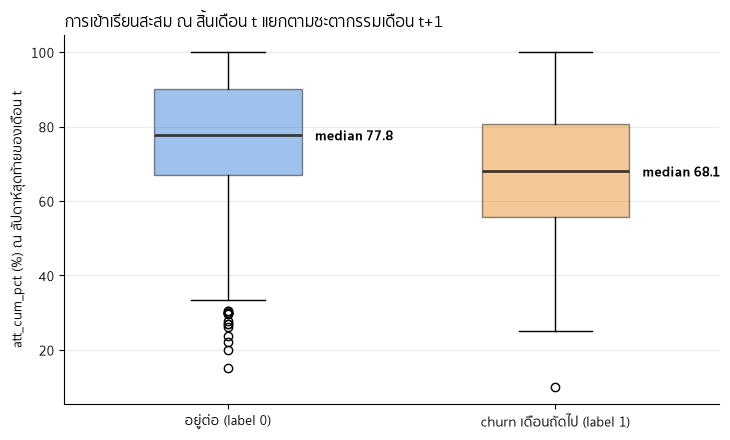

In [14]:
# boxplot เทียบสองกลุ่ม — คำนวณจากไฟล์ตรงๆ (รันได้เสมอ)
_wm = pd.read_csv(DATA_DIR / "weekly_metrics.csv", parse_dates=["week_start", "week_end"])
_wm["month"] = _wm["week_start"].dt.strftime("%Y-%m")
_snap = _wm.sort_values("week_start").groupby(["student_key", "month"], as_index=False).last()
_avl = (_lab.merge(_snap[["student_key", "month", "att_cum_pct"]],
                   on=["student_key", "month"], how="left")
            .dropna(subset=["churned_next_month"]))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
groups = [_avl.loc[_avl["churned_next_month"] == 0.0, "att_cum_pct"].dropna(),
          _avl.loc[_avl["churned_next_month"] == 1.0, "att_cum_pct"].dropna()]
box = ax.boxplot(groups, tick_labels=["อยู่ต่อ (label 0)", "churn เดือนถัดไป (label 1)"],
                 patch_artist=True, widths=0.45,
                 medianprops=dict(color="#40342F", lw=2))
for patch, c in zip(box["boxes"], [YEAR_COLORS[2568], YEAR_COLORS[2569]]):
    patch.set_facecolor(c)
    patch.set_alpha(0.45)
for i, g in enumerate(groups, start=1):    # direct label ที่ median (วางนอกกล่อง อ่านง่ายกว่า)
    ax.annotate(f"median {g.median():.1f}", (i + 0.24, g.median()), xytext=(6, -4),
                textcoords="offset points", fontsize=10, fontweight="bold")
ax.set_title("การเข้าเรียนสะสม ณ สิ้นเดือน t แยกตามชะตากรรมเดือน t+1", loc="left")
ax.set_ylabel("att_cum_pct (%) ณ สัปดาห์สุดท้ายของเดือน t")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### อ่าน boxplot

- **median ต่างกัน ~10 จุด** (77.8 vs 68.1) และกล่อง churn ทั้งกล่องถ่วงลงล่าง —
  attendance ต่ำ "มาก่อน" การหายจริง สัญญาณนี้ mentor รู้สึกมานาน วันนี้มีเลขยืนยันแล้ว
- แต่สังเกต **กล่องซ้อนกันเยอะ**: churner บางคนเข้าเรียน 90%+ (หายแบบไม่มีอาการ)
  และเด็กที่เข้าเรียน 60% จำนวนมากก็อยู่ต่อสบายๆ — attendance เดี่ยวๆ จึงเป็น
  signal ที่ดี แต่**ไม่พอ** ต้องให้โมเดลชั่งรวมกับ signal อื่นในบท 04–05

> ⚠️ **กับดัก correlation ≠ causation!** "เด็ก attendance ต่ำ churn เยอะ"
> **ไม่ได้**แปลว่า "บังคับให้เข้าเรียนแล้วจะไม่ churn" — attendance ต่ำมักเป็น *อาการ*
> ของสาเหตุร่วมตัวอื่น (ตามเนื้อหาไม่ทัน, ท้อ, ปัญหาที่บ้าน, ตารางชนกับโรงเรียน)
> ข่าวดีคือโมเดล **ทำนาย** ใช้ correlation ได้เต็มที่ — แค่ชี้ตัวถูกก็พอ
> แต่ **วิธีช่วย** ต้องหาสาเหตุจริงเป็นรายคน: mentor โทรไปเพื่อ*ฟัง*
> ไม่ใช่โทรไปสั่งให้เข้าเรียนเพิ่ม

## [แนวคิด] 3.4 พฤติกรรมก่อนหาย (2) — สัญญาณ "เงียบหาย"

`silent_weeks` คือตัวนับของระบบเรา: เรียนก็ไม่เข้า ข้อสอบก็ไม่แตะ ติดกันมากี่สัปดาห์แล้ว
— ความเงียบแบบนี้คือสิ่งที่ทีม mentor กลัวที่สุด เพราะน้องที่ "หายเงียบ" มักไม่โผล่มาบ่นก่อน
(คนที่บ่น = ยังอยากอยู่ต่อ!) คำถามคือ: ข้อมูลยืนยันความกลัวนี้ไหม?

คราวนี้ตัวแทนรายเดือนใช้ `.last()` ไม่ได้ — ถ้าน้องเงียบ 2 สัปดาห์กลางเดือนแล้ว
กลับมาสัปดาห์สุดท้าย ค่า `.last()` จะเป็น 0 เหมือนไม่เคยเกิดอะไรขึ้น
→ ใช้ **`.max()`**: "เดือนนี้เคยเงียบต่อเนื่องยาวสุดกี่สัปดาห์"

ปลายทางเป็นตัวแปรนับ (0, 1, 2, ...) ไม่เหมาะกับ boxplot → ใช้ `pd.crosstab`
ทำ**ตารางแจกแจงสัดส่วน**แทน โดย `normalize="columns"` ให้แต่ละกลุ่มรวมเป็น 1
(สองกลุ่มขนาดต่างกัน 10 เท่า เทียบจำนวนดิบไม่แฟร์ — ต้องเทียบสัดส่วน)

In [15]:
# ตัวอย่าง (เคสคู่ขนาน): สัดส่วนสี tier ของแต่ละปี — crosstab + normalize="columns"
tier_dist = pd.crosstab(wm["tier"], wm["year"], normalize="columns")
print((tier_dist * 100).round(1))
print("\nแต่ละคอลัมน์ (ปี) รวมได้ 100% → เทียบกันได้แม้สองปีมีจำนวนแถวไม่เท่ากัน")
print("ราวๆ 3 ใน 4 ของ (คน, สัปดาห์) เป็น green — ระบบ tier เดิมของเราค่อนข้างใจดี")

year    2568  2569
tier              
green   73.1  75.7
orange   5.7   5.5
red      3.1   2.0
yellow  18.2  16.8

แต่ละคอลัมน์ (ปี) รวมได้ 100% → เทียบกันได้แม้สองปีมีจำนวนแถวไม่เท่ากัน
ราวๆ 3 ใน 4 ของ (คน, สัปดาห์) เป็น green — ระบบ tier เดิมของเราค่อนข้างใจดี


### [แบบฝึกหัด 3.4] แจกแจง silent_weeks: churner vs stayer

เทียบการแจกแจง `silent_weeks` ของเดือน t ระหว่างคนที่หายเดือนถัดไป (label 1 —
เดือน t คือ**เดือนสุดท้ายก่อน churn** ของเขาพอดี) กับคนที่อยู่ต่อ (label 0)

**คำสั่ง**

1. สร้าง `silent_month`: ค่า **สูงสุด** ของ `silent_weeks` ต่อ (นักเรียน, เดือน) —
   `groupby(["student_key", "month"], as_index=False)["silent_weeks"].max()`
   (คอลัมน์ `month` ใน `wm` มีแล้วจากข้อ 3.3)
2. สร้าง `silent_vs_label`: merge กับ `labels` + ตัดแถว censored (ท่าเดียวกับข้อ 3.3)
3. สร้าง `silent_dist`: `pd.crosstab` ระหว่าง `silent_weeks` กับ `churned_next_month`
   โดย `normalize="columns"` — เก็บเป็นสัดส่วน 0–1

**ผลลัพธ์ที่คาด (sample):** ตาราง ~5 แถว (silent_weeks 0–4) × 2 คอลัมน์ (0.0, 1.0) —
ช่อง silent=0 ของกลุ่ม 0 ราวๆ 0.94 ส่วนของกลุ่ม 1 ราวๆ 0.86

In [16]:
____ = None  # TODO: เติมโค้ดแทน ____ ทีละจุด

# TODO 1: silent_weeks สูงสุดในเดือนนั้น ต่อ (นักเรียน, เดือน)
silent_month = (wm.groupby(["student_key","month"],as_index=False)["silent_weeks"].max())
# TODO 2: merge กับ labels แล้วตัดแถว label NaN (โครงเดียวกับข้อ 3.3)t
silent_vs_label = (labels.merge(silent_month,on=["student_key","month"],how="left").dropna(subset=["churned_next_month"]))

# TODO 3: ตารางสัดส่วน silent_weeks × churned_next_month (normalize ตามคอลัมน์)
silent_dist = pd.crosstab(silent_vs_label ["silent_weeks"], silent_vs_label ["churned_next_month"], normalize="columns")

if silent_dist is not None:
    print((silent_dist * 100).round(1))
checks.check("ex_03_04", silent_dist)

churned_next_month   0.0   1.0
silent_weeks                  
0.0                 94.5  86.3
1.0                  5.1   9.4
2.0                  0.3   2.6
3.0                  0.1   0.9
4.0                  0.0   0.9
ผ่าน ✓  (ex_03_04) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

- ขั้น 1 ต่างจากข้อ 3.3 สองจุด: หลัง groupby เลือกเฉพาะคอลัมน์ความเงียบคอลัมน์เดียว
  แล้วปิดด้วย "ค่าสูงสุด" แทน "ค่าสุดท้าย" (ไม่ต้อง sort ก่อน — ค่าสูงสุดไม่สนลำดับ)
- ขั้น 3: ตารางแจกแจงเอาค่าความเงียบเป็นแถว เอา label เป็นคอลัมน์
  แล้วสั่ง normalize ให้แต่ละคอลัมน์รวมเป็น 1

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `.groupby([..., ...], as_index=False)[...].max()`
- `.merge(..., on=[..., ...], how="left")` → `.dropna(subset=[...])`
- `pd.crosstab(..., ..., normalize="columns")`

</details>

In [17]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_03_04.py

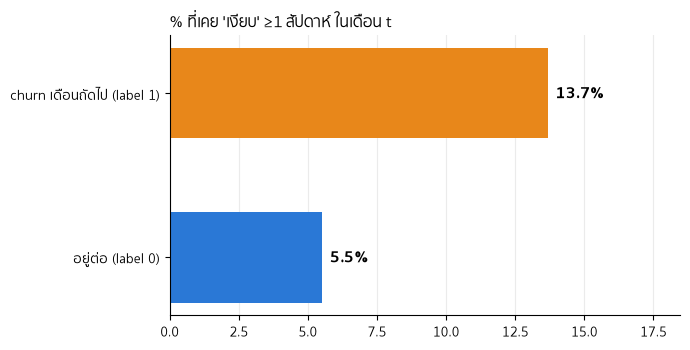

In [18]:
# สรุปเป็นเลขเดียวที่ mentor จำได้: เคยเงียบ ≥1 สัปดาห์ในเดือนนั้น มีสัดส่วนเท่าไร
_sil = _wm.groupby(["student_key", "month"], as_index=False)["silent_weeks"].max()
_svl = (_lab.merge(_sil, on=["student_key", "month"], how="left")
            .dropna(subset=["churned_next_month"]))
_share = _svl.groupby("churned_next_month")["silent_weeks"].apply(lambda s: (s >= 1).mean() * 100)

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.barh(["อยู่ต่อ (label 0)", "churn เดือนถัดไป (label 1)"],
               _share.values, color=[YEAR_COLORS[2568], YEAR_COLORS[2569]], height=0.55)
for b, v in zip(bars, _share.values):
    ax.annotate(f"{v:.1f}%", (v, b.get_y() + b.get_height() / 2), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=12, fontweight="bold")
ax.set_title("% ที่เคย 'เงียบ' ≥1 สัปดาห์ ในเดือน t", loc="left")
ax.set_xlim(0, max(_share.values) * 1.35)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### อ่านผล silent_weeks

- กลุ่ม churn เคยเงียบ ≥1 สัปดาห์ **13.7%** vs กลุ่มอยู่ต่อ **5.5%** —
  ความเสี่ยงต่างกัน **~2.5 เท่า** และยิ่งเงียบนาน (2–4 สัปดาห์) ยิ่งเทไปฝั่ง churn ชัด
- แต่มองมุมกลับ: churner **86%** ไม่มีสัปดาห์เงียบเลย! silent_weeks เป็นสัญญาณที่
  "แม่นตอนดัง แต่เงียบบ่อย" (precision สูง / recall ต่ำ — ศัพท์คู่นี้เจอจริงจังบท 05)
  → ใช้เดี่ยวๆ จะพลาดน้องส่วนใหญ่ ใช้รวมกับ attendance + เดือนของซีซัน ถึงจะครบเครื่อง
- โยงกับระบบ tier เดิมของเรานิดนึง: สีตัดจาก **% การเข้าเรียน** เป็นหลัก
  (≥75 เขียว / ≥50 เหลือง / ≥25 ส้ม / ต่ำกว่านั้นแดง) แล้วมี**กฎเสริม**ทับอีกชั้น:
  เงียบติดกัน ≥2 สัปดาห์ = แดงทันที — ใน sample แถวสีแดงราว **77% มาจาก attendance ต่ำ**
  มีแค่ ~23% ที่แดงเพราะกฎความเงียบ
- silent_weeks จึงเป็น signal เสริมที่ tier จับไม่ครบ: เด็กที่ "หายเงียบ" บางคน
  ยังไม่ทันแดงด้วยเกณฑ์เข้าเรียนก็ churn ไปก่อนแล้ว — โมเดลบท 05
  ต้องพิสูจน์ว่าชนะ heuristic tier ตัวนี้ให้ได้

## [แนวคิด] 3.5 เปิดสนามอิสระ — คำถามของคุณเอง

ถึงตรงนี้คุณมีท่าครบมือแล้ว: merge → groupby → mean/size → (pivot/crosstab ถ้าอยากหรู)
ข้อสุดท้ายไม่มีสูตรตายตัวครับ — **เลือกมุมที่คุณสงสัยเองแล้วไปหาคำตอบ**
นี่แหละงาน data analyst ของจริง: ตั้งคำถามเก่งสำคัญกว่าจำ syntax ได้

คำถามที่ทีมเราเถียงกันบ่อย (เลือกจากนี้ หรือคิดเองเลยก็ได้):

- น้องดู**เทป** churn มากกว่าน้องเรียน**สด**จริงไหม? (`live_or_replay` ใน `students`)
- ลงเรียน**น้อยวิชา** = ผูกพันน้อย = หายง่ายกว่า? (`n_subjects`)
- **น้องเก่า** (`old_new`) อยู่ทนกว่าน้องใหม่แค่ไหน?
- โรงเรียนเป้าหมาย (`target_school`) มีผลไหม — สาย MWIT อึดกว่าสาย TU?
- สมัครช้า (`signup_lateness`) แล้วตามเพื่อนไม่ทัน เลยถอดใจง่าย?

ตารางไหนอยู่คนละใบ ก็ merge เข้ามาก่อนด้วย `student_key` — ดูตัวอย่างข้างล่างเป็นโครง

In [19]:
# ตัวอย่าง (เคสคู่ขนาน): churn rate แยกชั้นเรียน — merge students เข้ามา แล้ว groupby
by_grade = (labels.merge(students[["student_key", "grade"]], on="student_key")
                  .groupby("grade")["churned_next_month"].mean())
print((by_grade * 100).round(1))
print("\nม.3 หายมากสุด (~11%) — ใกล้สนามสอบจริง เปลี่ยนแผนได้ทุกเมื่อ · ม.2 นิ่งสุด (~7%)")
print("ระวังด้วย: กลุ่มเล็กๆ ค่าจะเหวี่ยง — ดูจำนวนแถวประกอบด้วย .size() ก็ดีครับ")

grade
ม.1     8.7
ม.2     6.8
ม.3    10.8
Name: churned_next_month, dtype: float64

ม.3 หายมากสุด (~11%) — ใกล้สนามสอบจริง เปลี่ยนแผนได้ทุกเมื่อ · ม.2 นิ่งสุด (~7%)
ระวังด้วย: กลุ่มเล็กๆ ค่าจะเหวี่ยง — ดูจำนวนแถวประกอบด้วย .size() ก็ดีครับ


### [แบบฝึกหัด 3.5] มุมของคุณเอง 1 มุม

**คำสั่ง**

1. เลือก 1 คำถามจากลิสต์ด้านบน (หรือคิดเอง)
2. merge ตารางที่ต้องใช้ แล้ว groupby คำนวณ churn rate (หรือ metric อื่นที่ตอบคำถามคุณ)
3. เก็บผลไว้ในตัวแปร `my_view` — เป็น Series หรือ DataFrame ที่**สรุปต่อกลุ่มแล้ว**
   (ไม่ใช่ข้อมูลรายแถวดิบๆ)
4. ดูผลแล้วเขียนสรุป 1 ประโยคในหัว: เห็นอะไร แล้วอยากบอก mentor ว่าอะไร

check ข้อนี้ตรวจแค่โครงสร้างหลวมๆ (สรุปเป็นกลุ่มแล้วจริง มีตัวเลขจริง) —
คำตอบ "ถูก" มีหลายแบบครับ ขอแค่ตอบคำถามที่คุณตั้งเองได้จริง

In [20]:
____ = None  # TODO: เลือกมุมของคุณเอง แล้วเขียน merge + groupby ให้จบในตัวแปรเดียว

# ไอเดีย: live_or_replay · n_subjects · old_new · target_school · signup_lateness
my_view = (labels.merge(students,on= "student_key", how = "left").groupby("grade",as_index=False)["churned_next_month"].sum()).dropna(subset="grade")


if my_view is not None:
    print(my_view)
checks.check("ex_03_05", my_view)

  grade  churned_next_month
0   ม.1                15.0
1   ม.2                40.0
2   ม.3                62.0
ผ่าน ✓  (ex_03_05) เยี่ยมมากครับ 🎉


True

In [21]:
exam = pd.read_csv(DATA_DIR / "exam_attempts.csv", parse_dates=["submitted_at"])
exam["month"] = exam["submitted_at"].dt.strftime("%Y-%m")

attempts_month = exam.groupby(["student_key","month"],as_index=False).size().rename(columns={"size": "n_attempts"})

base = labels.merge(attempts_month,on=["student_key","month"],how="left").dropna(subset=["churned_next_month"])
base["n_attempts"] = base["n_attempts"].fillna(0).astype(int)
base["n_bin"] = base["n_attempts"].clip(upper=5)

my_view=base.groupby("n_bin")["churned_next_month"].agg(["mean","size"])
if my_view is not None:
    print(my_view)
checks.check("ex_03_05", my_view)

           mean  size
n_bin                
0      0.235294    17
1      0.173077    52
2      0.143939   132
3      0.105820   189
4      0.076923   221
5      0.066482   722
ผ่าน ✓  (ex_03_05) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

ลอกโครงตัวอย่าง by_grade แล้วเปลี่ยนคอลัมน์ที่ merge/groupby เป็นมุมที่คุณเลือก
— อยากได้ทั้ง churn rate และจำนวนแถวพร้อมกัน ให้ปิดท้ายด้วยตัวสรุปสองตัวในคำสั่งเดียว
(ดูชื่อ function ในคำใบ้ 2)

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `.merge(..., on="student_key")`
- `.groupby(...)[...].mean()` — หรือ `.agg(["mean", "size"])` ถ้าอยากได้จำนวนแถวคู่กัน

</details>

In [22]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_03_05.py

## สรุปสิ่งที่ได้จากบทนี้

(ทั้งหมดนี้คือ sample — เลขจริงรอ label sheet ของคุณเสร็จ แต่ *วิธีดู* ใช้ซ้ำได้ทันที)

| Signal | ที่เห็นในข้อมูล | ว่าที่ feature (บท 04) |
|---|---|---|
| เดือนของซีซัน | peak ก.ค.–ส.ค. + เดือนแรกของน้องใหม่ | `month_index`, `months_enrolled` |
| การเข้าเรียน | median ต่างกัน ~10 จุด (77.8 vs 68.1) | `att_cum_pct`, `att_month_pct`, `att_delta` |
| ความเงียบ | เคยเงียบ ≥1 สัปดาห์ → เสี่ยง ~2.5 เท่า | `max_silent_weeks` |
| รูปแบบการเรียน (ข้อ 3.5) | เทปหายมากกว่าสด ~2 เท่า · 2 วิชาหายมากสุด | `live_or_replay`, `n_subjects` |
| ขาลง survival | ปี 69 เดือนแรกดิ่งแรง (ทดลองเรียน) | `old_new`, `signup_lateness` |

และบทเรียนคิด 2 เรื่องที่แพงกว่าโค้ด: **correlation ≠ causation**
(โมเดลชี้ตัวได้ แต่วิธีช่วยต้องให้ mentor ไปฟังสาเหตุจริง) และ **survivorship bias**
(ค่าเฉลี่ยปลายซีซันดูดีเพราะคนที่ไม่ไหวออกไปหมดแล้ว)

**บทถัดไป → บท 04: Feature Engineering** — เอา signal ทุกแถวในตารางนี้
ไปแปลงเป็นคอลัมน์ตัวเลขราย (นักเรียน, เดือน) ภายใต้กฎเหล็ก
"ยืนที่สิ้นเดือน t มองย้อนหลังเท่านั้น" — แล้วคุณจะเจอกับดัก leakage แบบจังๆ 1 ครั้ง
เตรียมตัวให้ดีครับ 💪